In [1]:
import os
import urllib
from pathlib import Path
import cv2
import pylupnt as pnt
import numpy as np
import numpy.linalg as LA
import pandas as pd
from PIL import Image
import spiceypy as spice
import plotly.graph_objects as go

from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R
from astropy.coordinates import cartesian_to_spherical, spherical_to_cartesian
from pylupnt.crater_detection.common.camera import Camera
from pylupnt.crater_detection.common.coordinates import ENU_system, nadir_attitude

from pylupnt.crater_detection.common.robbins import extract_robbins_dataset, load_craters
from pylupnt.crater_detection.matching.projective_invariants import conic_matrix, matrix_adjugate
import pylupnt.crater_detection.common.constants as const
from pylupnt.crater_detection.common.conics import *

Read blend: "/Users/guillemcv/Development/NavLab/LuPNT/data/surface/Moon.blend"


In [2]:
_BASE_URL = 'https://naif.jpl.nasa.gov/pub/naif/'
_KERNEL_ROOT = Path('../data/spice_kernels')

def download_kernel(file_path, base_url=_BASE_URL, base_folder=_KERNEL_ROOT):
    if isinstance(file_path, str):
        file_path = Path(file_path)

    local_path = base_folder / file_path
    url = base_url + file_path.as_posix()

    # Create necessary sub-directories in the DL_PATH direction
    local_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        # If the file is not present in the download directory -> download it
        if not os.path.isfile(local_path):
            print(f"Downloading {url}", end="  ")
            # Download the file with the urllib  package
            urllib.request.urlretrieve(str(url), str(local_path))
            print("Done.")
        else:
            print(f"{base_folder / file_path} already exists!")
    except urllib.error.HTTPError as e:
        print(f"Error: \n{url} could not be found: ", e)

kernels = list(map(Path, [
    'generic_kernels/lsk/naif0012.tls',
    'generic_kernels/pck/pck00010.tpc',
    'pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/spk/de421.bsp',
    'pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/pck/moon_pa_de421_1900_2050.bpc',
    'pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/fk/moon_assoc_pa.tf',
    'pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/fk/moon_080317.tf'
]))

for k in kernels:
    download_kernel(k)

spice.furnsh(map(str, list(map(lambda x: _KERNEL_ROOT / x, kernels))))

../data/spice_kernels/generic_kernels/lsk/naif0012.tls already exists!
../data/spice_kernels/generic_kernels/pck/pck00010.tpc already exists!
../data/spice_kernels/pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/spk/de421.bsp already exists!
../data/spice_kernels/pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/pck/moon_pa_de421_1900_2050.bpc already exists!
../data/spice_kernels/pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/fk/moon_assoc_pa.tf already exists!
../data/spice_kernels/pds/data/lro-l-spice-6-v1.0/lrosp_1000/data/fk/moon_080317.tf already exists!


In [3]:
# convert the datetime to a string, replacing the time with midnight
DATE = '2020-05-15T00:00:00'

# convert the utc midnight string to the corresponding ET
ET_DATE = spice.utc2et(DATE)

SUN_POS, _ = spice.spkpos(targ='SUN', et=ET_DATE, ref='ECLIPJ2000', abcorr='NONE', obs='EARTH')
SUN_POS *= 1e3  # Convert to m

MOON_POS, _ = spice.spkpos(targ='MOON', et=ET_DATE, ref='ECLIPJ2000', abcorr='NONE', obs='EARTH')
MOON_POS *= 1e3  # Convert to m

print(f"Distance to Sun = {LA.norm(SUN_POS)/1e3:.0f}km\nDistance to Moon = {LA.norm(MOON_POS)/1e3:.0f}km")

Distance to Sun = 151229439km
Distance to Moon = 399289km


In [22]:
# Image setup:
fov = 45
N = (2048, 2048)
pnt.render.SCENE["fov"] = fov
pnt.render.ENGINE = pnt.render.EEVEE
pnt.render.SCENE["resx"] = N[0]
pnt.render.SCENE["resy"] = N[1]
pnt.render.SCENE["rendSamples"] = 64
pnt.render.update_scene()

t_tai = pnt.SpiceInterface.string_to_tai("2020-05-15T00:00:00")
r_sun_mi = pnt.SpiceInterface.get_body_pos(pnt.SUN, t_tai, pnt.MI, pnt.MOON, "NONE")[:3]
r_sun_mi_ = pnt.SpiceInterface.get_body_pos_vel(t_tai, pnt.MOON, pnt.SUN)[:3]

In [23]:
SUN_POS - MOON_POS, r_sun_mi, r_sun_mi_

(array([8.77912204e+10, 1.23099280e+11, 2.49222992e+07]),
 array([8.77912204e+07, 1.12931468e+08, 4.89889473e+07]),
 array([-1071725.34342306,  1142350.07625693,   537682.02714886]))

In [24]:
# The following extracts all craters with the given parameters and returns their lat, long, psi (angle) in radians, and
# major and minor axis in km.
lat, lon, major, minor, psi, crater_id = extract_robbins_dataset(
    load_craters(pnt.utils.find_file("lunar_crater_database_robbins_2018.csv"), diamlims=[20, 250], ellipse_limit=1.4)
)

In [25]:
### POSITION CAMERA
height = 1000
dist = pnt.R_MOON + height

p_Mi = np.array(spherical_to_cartesian(pnt.R_MOON, lat, lon)).T[:, :, None]
r_M = np.array(spherical_to_cartesian(dist, np.radians(-43.31), np.radians(-11.36)))[:, None]
dist = height / np.cos(np.radians(fov/2)*np.sqrt(2)*1.5)
visible = (np.sqrt(np.sum(np.square(p_Mi - r_M), axis=1)) < dist).ravel()
p_Mi = p_Mi[visible]
r_M

array([[ 1952.85443801],
       [ -392.34594634],
       [-1877.7068361 ]])

In [36]:
r_cam_pa = pnt.FrameConverter.convert(t_tai, r_M, pnt.MI, pnt.PA)
# r_geo = np.array([-71.50, 91.31, 500])
# r_geo[:2] = np.deg2rad(r_geo[:2])
# r_cam_pa = pnt.geographical_to_cartesian(r_geo, pnt.R_MOON)
r_sun_pa = pnt.FrameConverter.convert(t_tai, r_sun_mi, pnt.MI, pnt.PA)
X_ax_cam, Y_ax_cam, Z_ax_cam = nadir_attitude(r_cam_pa[:, None])
T_CM = np.concatenate((X_ax_cam, Y_ax_cam, Z_ax_cam), axis=-1)
R_pa2cam = T_CM.T

pnt.render.render(r_cam_pa, R_pa2cam, r_sun_pa, "./tmp.png", frame="OpenCV")
im = Image.open("./tmp.png")
im.show()

Fra:0 Mem:1426.99M (Peak 1426.99M) | Time:00:00.00 | Syncing Sun
Fra:0 Mem:1426.99M (Peak 1426.99M) | Time:00:00.00 | Syncing Camera
Fra:0 Mem:1427.00M (Peak 1427.00M) | Time:00:00.00 | Syncing Moon
Fra:0 Mem:1457.12M (Peak 1457.12M) | Time:00:00.01 | Rendering 1 / 32 samples
Fra:0 Mem:1427.03M (Peak 1457.12M) | Time:00:00.23 | Rendering 26 / 32 samples
Fra:0 Mem:1427.09M (Peak 1457.12M) | Time:00:00.23 | Rendering 32 / 32 samples
Saved: 'tmp.png'
Time: 00:00.56 (Saving: 00:00.10)



In [28]:
fig = go.Figure()
r1 = r_cam_pa / LA.norm(r_cam_pa)
r2 = r_sun_pa / LA.norm(r_sun_pa)
fig.add_scatter3d(x=[0, r1[0]], y=[0, r1[1]], z=[0, r1[2]], mode="lines+markers", marker=dict(size=10))
fig.add_scatter3d(x=[0, r2[0]], y=[0, r2[1]], z=[0, r2[2]], mode="lines+markers", marker=dict(size=10))
pnt.plot.plot_frame(fig, r1, R_pa2cam, length_scale=0.5, tip_scale=0.2)
fig.show()

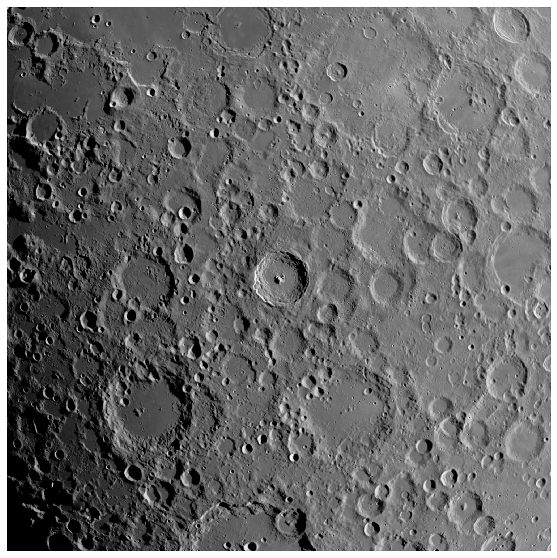

In [27]:
### ROTATE CAMERA
k = np.array([0., 0., 1.])[:, None]
CAM_POS = MOON_POS + r_M.ravel()*1e3

X_ax_cam, Y_ax_cam, Z_ax_cam = nadir_attitude(r_M)

T_CM = np.concatenate((X_ax_cam, Y_ax_cam, Z_ax_cam), axis=-1)
if LA.matrix_rank(T_CM) != 3:
    raise ValueError("Invalid camera attitude matrix!")


s.setObjectAttitude('moon', quat(vec3(1,0,0), 0))
s.setObjectAttitude('moon', R.from_euler('z', np.pi, degrees=False).as_quat())

s.setObjectPosition('camera', CAM_POS)
s.setObjectAttitude('camera', R.from_matrix(T_CM).as_quat())
# look_at(s, CAM_POS, MOON_POS)

s.render()
im = s.getImageGray32F()
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im, aspect='equal', interpolation='none', cmap='Greys_r', origin='upper')
ax.set_axis_off()
# fig.savefig('output/surrender_example.png')

### Mathematical Representation of a Crater
Pages 20 - 25 from [Christian, J. A., Derksen, H., & Watkins, R. (2020). Lunar Crater Identification in Digital Images](http://arxiv.org/abs/2009.01228)

#### Convert coordinates to 3D selenographic position
`load_robbins_dataset` extracts all craters with the given parameters and returns their lat, long, psi (angle) in radians, and
major and minor axis in kms.
Filter dataset using latitude & longitude limits using `latlims` and `longlims` parameters.

3D selenographic position is determined using their latitude $\varphi$ & longitude $\lambda$ along with distance
from center $\rho$:

$\rho_i \begin{bmatrix}
\cos\varphi_i\cos\lambda_i \\
\cos\varphi_i\sin\lambda_i \\
\sin\varphi_i
\end{bmatrix}$,

#### Define local ENU coordinate system per crater
$ \mathbf{u}_i = \frac{\mathbf{p}^{(c)}_{M_i}}{||\mathbf{p}^{(c)}_{M_i}||} $,
$ \mathbf{e}_i = \frac{\mathbf{k} \times \mathbf{u}_i}{|| \mathbf{k} \times \mathbf{u}_i ||} $,
$ \mathbf{n}_i = \frac{\mathbf{u}_i \times \mathbf{e}_i}{|| \mathbf{u}_i \times \mathbf{e}_i ||} $,

with $ k = \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}^T $,

results in attitude transformation matrix

$ T^{E_i}_M = \begin{bmatrix} \mathbf{e}_i & \mathbf{n}_i & \mathbf{u}_i \end{bmatrix} $

In [30]:
T_EM = np.concatenate(ENU_system(p_Mi), axis=-1)

#### Define relation between point in 2D ellipse plane and 3D selenographic frame

$ H_{M_i} = \begin{bmatrix}
             T^{E_i}_M \mathbf{S} &  \mathbf{p}^{(c)}_{M_i}
           \end{bmatrix} $

$ \mathbf{S} = \begin{bmatrix}
                    \mathbf{I}_{2\times2} \\
                    \mathbf{0}_{1\times2}
                \end{bmatrix}
$

In [31]:
S = np.concatenate((np.identity(2), np.zeros((1, 2))), axis=0)
H_Mi = np.concatenate((T_EM @ S, p_Mi), axis=-1)

### Homography and Action of a Projective Camera on a Crater Disk Quadric

#### Define camera calibration matrix

The conversion between image plane coordinates ($\mathbf{\bar{x}}_C$) and digital image pixel coordinates
($\mathbf{\bar{u}}_C$) is described the following affine transformation:

$ \mathbf{K} = \begin{bmatrix}
    d_x & \alpha & u_p \\
    0   & d_y    & v_p \\
    0   & 0      & 1
\end{bmatrix} $,

$ \mathbf{\bar{u}}_C = \mathbf{K} \mathbf{\bar{x}}_C$

In [32]:
f_x = (N[0]/2) / np.tan(np.radians(fov)/2)
f_y = (N[1]/2) / np.tan(np.radians(fov)/2)

K = np.array([[f_x, 0,       N[0]/2],
             [0,    f_y,     N[1]/2],
             [0,    0,       1]])

Using camera position in camera reference frame $C$  ($\mathbf{r }_C$) and the camera attitude $\mathbf{T}^M_C$ the camera projection matrix is as follows:

$ \mathbf{P}^M_C = \mathbf{K} \begin{bmatrix} \mathbf{T}^M_C & -r_C \end{bmatrix}$

With this, the homography to project the crater's disk quadric into its apparent ellipse in the image plane is found:

$ \mathbf{H}_{C_i} =  \mathbf{P}^M_C \begin{bmatrix}H_{M_i} \\ k^T \end{bmatrix} $

Using the [matrix representation of an ellipse](https://en.wikipedia.org/wiki/Matrix_representation_of_conic_sections)
the ellipse in the local crater plane $\mathbf{C}_i$ can be transformed to the image plane:

$ \mathbf{A_i} \propto \mathbf{H}_{C_i}^{-T} \mathbf{C}_i \mathbf{H}_{C_i}^{-1} $

In [33]:
k = np.array([0., 0., 1.])[:, None]
T_MC = LA.inv(T_CM)
r_C = T_MC @ r_M
# P_MC = K @ np.concatenate((T_MC, -r_C), axis=1)
P_MC = K @ T_MC @ np.concatenate((np.identity(3), -r_M), axis=1)
H_Ci = P_MC @ np.concatenate((H_Mi, np.tile(k.T[None, ...], (len(H_Mi), 1, 1))), axis=1)

C_i = conic_matrix(major[visible], minor[visible], psi[visible])
A_i =  LA.inv(H_Ci).transpose((0, 2, 1)) @ C_i @ LA.inv(H_Ci)

#### Overlay output onto render

In [34]:
# ax.set_axis_off()
# fig.savefig('output/demonax_overlaid.png')

/Users/guillemcv/Development/NavLab/LuPNT/python/pylupnt/crater_detection/common/conics.py:145: RuntimeWarning:

invalid value encountered in sqrt



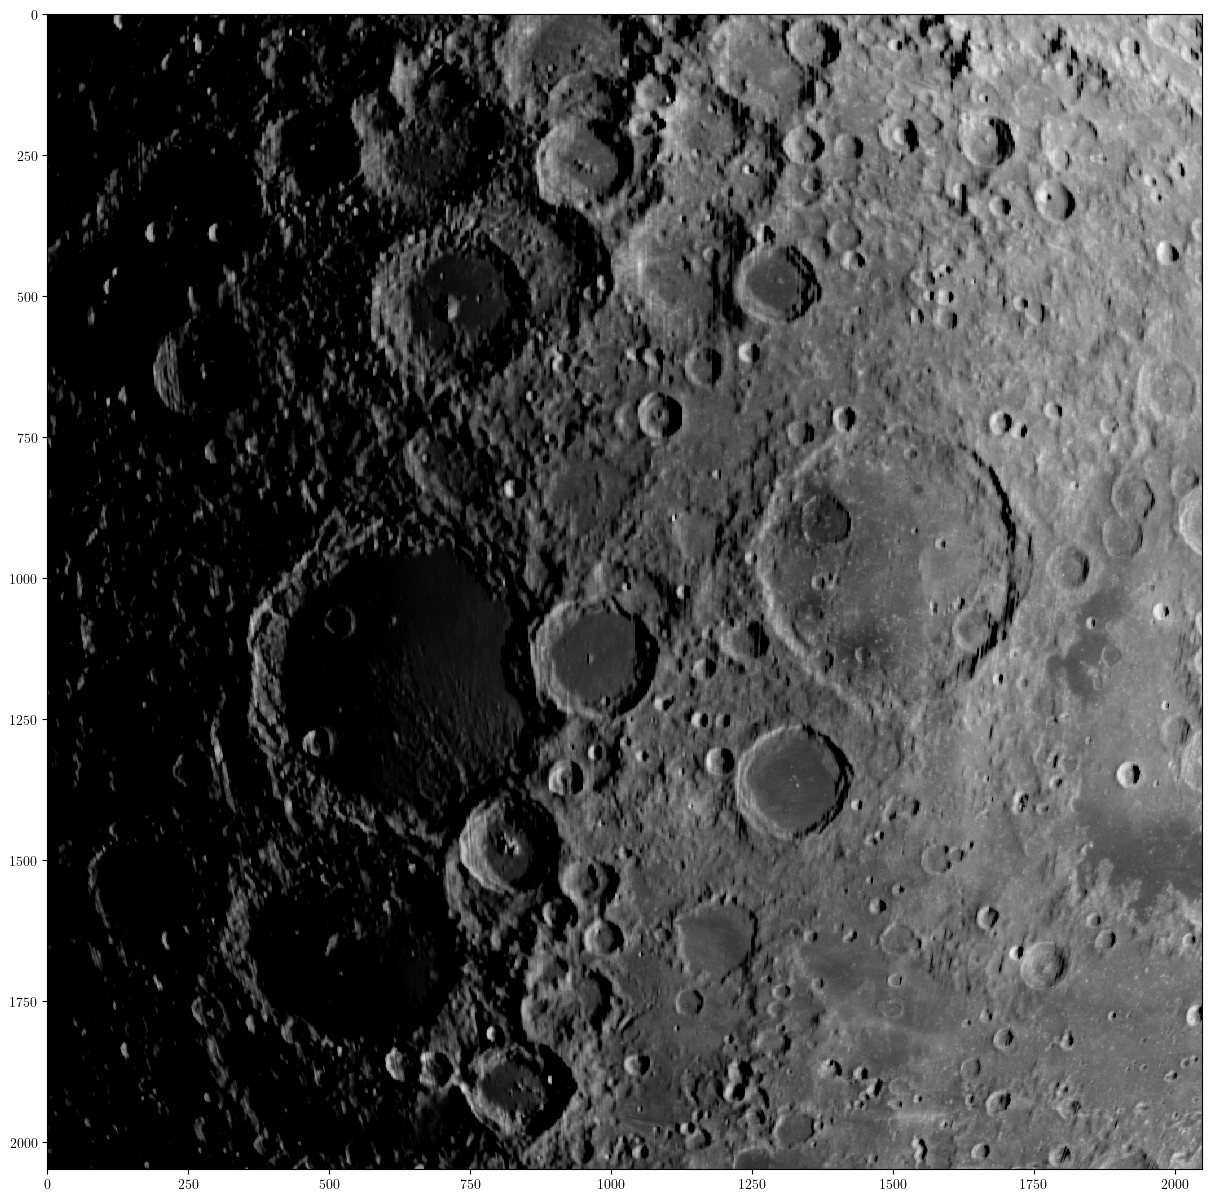

In [37]:
cam = Camera(resolution=N, fov=fov)
a_proj, b_proj = ellipse_axes(A_i)
psi_proj = ellipse_angle(A_i)
r_pix_proj = conic_center(A_i)


from matplotlib.collections import EllipseCollection
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'aspect': 'equal'})
ax.imshow(im, aspect='equal', interpolation='none', cmap='gray')
ec = EllipseCollection(a_proj, b_proj, np.degrees(psi_proj), units='xy', offsets=r_pix_proj,
                       transOffset=ax.transData, facecolors="None", edgecolors='w')
ax.add_collection(ec)

ax.scatter(*project_crater_centers(p_Mi, fov, N, T_CM, r_M).T, c='r', s=1.2, marker='x')

ax.set_xlim(0, N[0])
ax.set_ylim(N[1], 0)

plt.show()
# fig.savefig('output/tycho_overlaid.png')

/Users/guillemcv/Development/NavLab/LuPNT/python/pylupnt/crater_detection/common/conics.py:215: RuntimeWarning:

invalid value encountered in cast



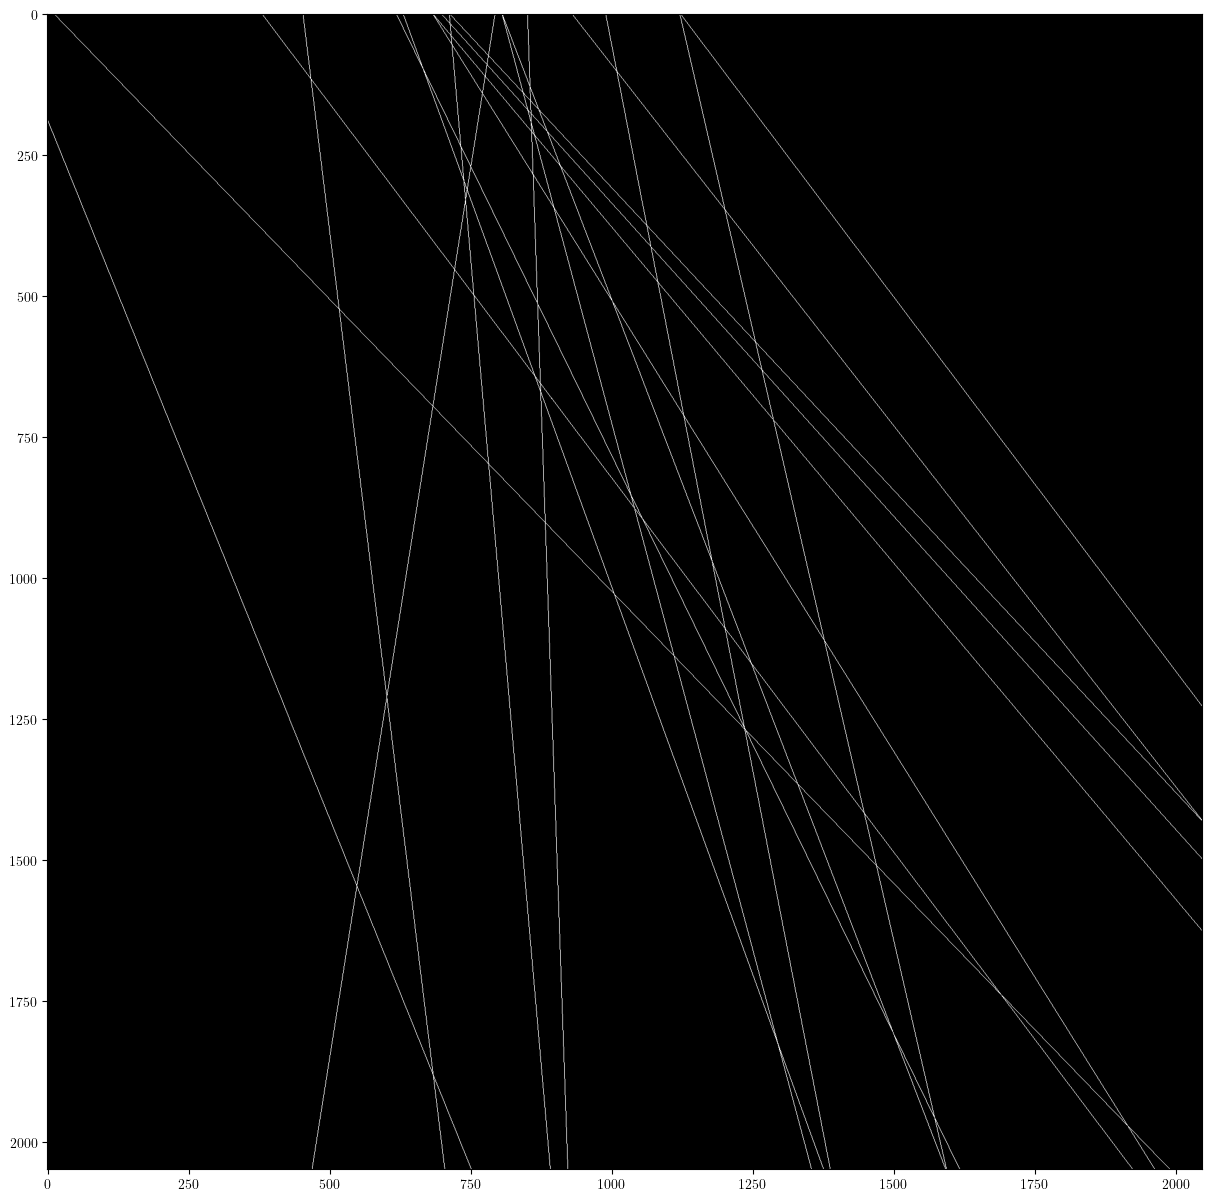

In [38]:
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'aspect': 'equal'})
ax.imshow(generate_mask(A_i, cam.resolution), cmap='Greys_r')